## 0. Setup

Import all the libraries needed for the project. No installation required — everything here is already available on Kaggle.

In [1]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from itertools import combinations

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 1. Data Understanding

Load the dataset and take a first look at its shape, columns, and any missing values.

In [2]:
candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
print("CSV files found:")
for c in candidates:
    print(" -", c)

CSV_PATH = candidates[0] if candidates else "shopping_behaviour.csv"
print("\nUsing:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

CSV files found:
 - /kaggle/input/datasets/saadaliyaseen/shopping-behaviour-dataset/shopping_behavior_updated (1).csv

Using: /kaggle/input/datasets/saadaliyaseen/shopping-behaviour-dataset/shopping_behavior_updated (1).csv
(3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### 1.1 Check for missing values

In [3]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Series([], dtype: int64)


### 1.2 Define the target variable

We predict `Subscription Status` (Yes/No) — a genuine binary column in this dataset — rather than a general purchase flag, since every row here is already a completed purchase.

In [4]:
TARGET_COL = "Subscription Status"

y_raw = df[TARGET_COL]
print(y_raw.value_counts())

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64


## 2. Data Preparation

Separate features from the target, and prepare text columns for encoding.

In [5]:
id_like = ["Customer ID"]
feature_cols = [c for c in df.columns if c not in id_like + [TARGET_COL]]

numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

X = df[feature_cols].copy()
y = LabelEncoder().fit_transform(df[TARGET_COL])

Numeric features: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
Categorical features: ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']


### 2.1 Select features (excluding near-perfect predictors)

Gender, Discount Applied, and Promo Code Used are excluded from the model's inputs — the crosstab showed they almost perfectly determine Subscription Status on their own, which would make the classification task trivial rather than a meaningful test of the models. They're noted as a finding, not used as inputs.

In [6]:
id_like = ["Customer ID"]
leak_like = ["Gender", "Discount Applied", "Promo Code Used"]  # near-perfect predictors, excluded on purpose

feature_cols = [c for c in df.columns if c not in id_like + leak_like + [TARGET_COL]]

numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print("Excluded (ID):", id_like)
print("Excluded (near-perfect predictors):", leak_like)
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

X = df[feature_cols].copy()
y = LabelEncoder().fit_transform(df[TARGET_COL])

Excluded (ID): ['Customer ID']
Excluded (near-perfect predictors): ['Gender', 'Discount Applied', 'Promo Code Used']
Numeric features: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
Categorical features: ['Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Shipping Type', 'Payment Method', 'Frequency of Purchases']


In [7]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])

X_processed = preprocessor.fit_transform(X)
feature_names = (numeric_cols +
                  list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)))
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
X_processed_df.shape

(3900, 135)

## 3. Clustering (K-means)

Group customers by similarity, independent of Subscription Status. First, test a range of cluster counts (k) to find a reasonable number of segments.

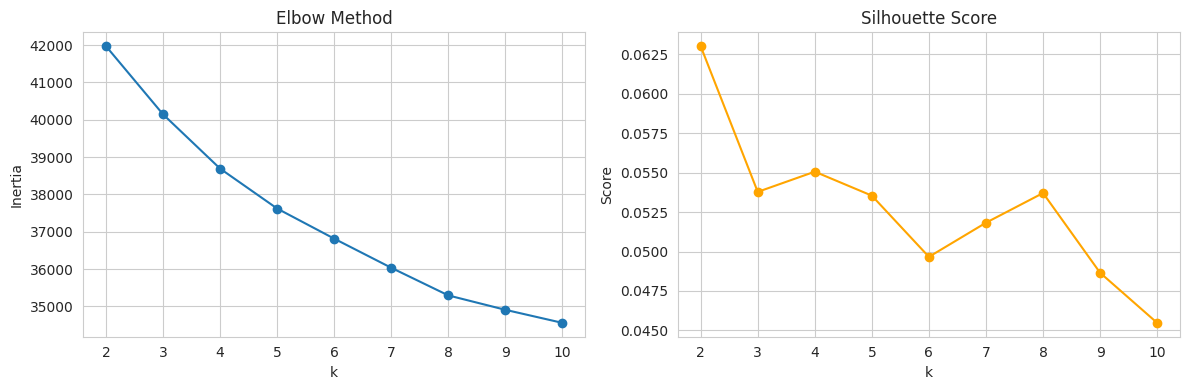

Suggested k (highest silhouette score): 2


In [8]:
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_processed, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Suggested k (highest silhouette score):", best_k)

### 3.1 Fit final K-means model

Silhouette scores were low across all tested k values (likely due to the high-dimensional, mostly categorical feature space), with no dramatically clear winner. k=4 was chosen as a reasonable balance — a local peak in the silhouette score, and few enough groups to describe meaningfully.

In [9]:
K_FINAL = 4

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_processed)

df["Cluster"] = cluster_labels
print(f"Final model: k={K_FINAL}, silhouette={silhouette_score(X_processed, cluster_labels):.3f}")
df["Cluster"].value_counts().sort_index()

Final model: k=4, silhouette=0.055


Cluster
0     922
1     992
2     960
3    1026
Name: count, dtype: int64

### 3.2 Cluster profiling

Look at the average numeric values and dominant categories per cluster, to understand what distinguishes each customer segment.

In [10]:
profile = df.groupby("Cluster")[numeric_cols].mean()
profile

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Cluster,,,,
0,32.196312,69.390456,3.123319,21.496746
1,56.058468,81.159274,4.006754,27.271169
2,31.651042,52.002083,4.411667,24.850000
3,54.763158,37.691033,3.445614,27.428850


In [11]:
for col in categorical_cols[:5]:
    print(f"\n--- {col} distribution by cluster (top categories) ---")
    print(df.groupby("Cluster")[col].value_counts(normalize=True).groupby(level=0).head(3))


--- Item Purchased distribution by cluster (top categories) ---
Cluster  Item Purchased
0        Shirt             0.061822
         Pants             0.049892
         Sunglasses        0.047722
1        Dress             0.053427
         Blouse            0.048387
         Scarf             0.046371
2        Belt              0.053125
         Gloves            0.047917
         Hat               0.047917
3        Sunglasses        0.049708
         Coat              0.048733
         Jacket            0.048733
Name: proportion, dtype: float64

--- Category distribution by cluster (top categories) ---
Cluster  Category   
0        Clothing       0.475054
         Accessories    0.303688
         Footwear       0.142082
1        Clothing       0.449597
         Accessories    0.311492
         Footwear       0.159274
2        Clothing       0.439583
         Accessories    0.334375
         Footwear       0.151042
3        Clothing       0.420078
         Accessories    0.321637
   

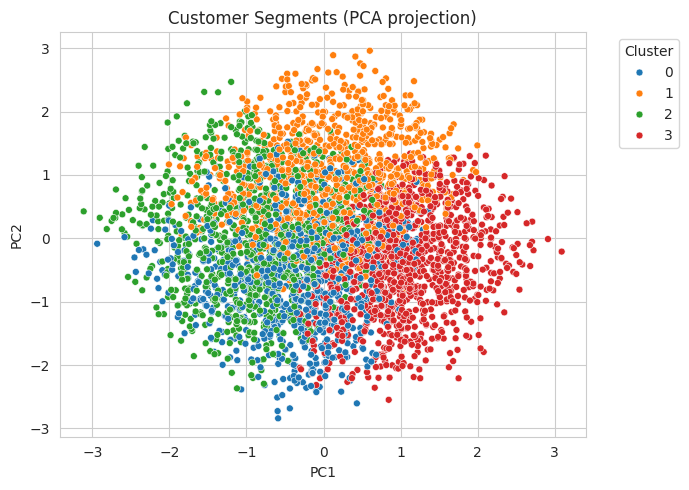

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_processed)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["Cluster"], palette="tab10", s=25)
plt.title("Customer Segments (PCA projection)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Classification

Predict Subscription Status using the same features as before, plus cluster membership as an extra input. Two models are trained and compared: an Artificial Neural Network and a rule-based (decision tree) classifier.

In [13]:
X_with_cluster = X.copy()
X_with_cluster["Cluster"] = df["Cluster"].astype(str)  # treat as categorical

categorical_cols_clf = categorical_cols + ["Cluster"]

preprocessor_clf = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols_clf),
])

X_train, X_test, y_train, y_test = train_test_split(
    X_with_cluster, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

X_train_proc = preprocessor_clf.fit_transform(X_train)
X_test_proc = preprocessor_clf.transform(X_test)
print(X_train_proc.shape, X_test_proc.shape)

(2925, 139) (975, 139)


### 4.1 Artificial Neural Network

Initial attempt without rebalancing collapsed to always predicting the majority class ("No"), since the remaining signal after excluding Gender/Discount/Promo is weak and the classes are imbalanced. We address this by oversampling the minority class in the training set only.

In [14]:
from sklearn.utils import resample

train_df = pd.DataFrame(X_train_proc)
train_df["target"] = y_train.values if hasattr(y_train, "values") else y_train

majority = train_df[train_df["target"] == 0]
minority = train_df[train_df["target"] == 1]

minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=RANDOM_STATE)
train_balanced = pd.concat([majority, minority_upsampled])

X_train_bal = train_balanced.drop(columns=["target"]).values
y_train_bal = train_balanced["target"].values

print("Balanced training set size:", len(train_balanced))
print(pd.Series(y_train_bal).value_counts())

Balanced training set size: 4270
0    2135
1    2135
Name: count, dtype: int64


In [15]:
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
ann.fit(X_train_bal, y_train_bal)
ann_preds = ann.predict(X_test_proc)

print(classification_report(y_test, ann_preds))

              precision    recall  f1-score   support

           0       0.72      0.78      0.75       712
           1       0.24      0.19      0.21       263

    accuracy                           0.62       975
   macro avg       0.48      0.49      0.48       975
weighted avg       0.59      0.62      0.61       975



### 4.2 Rule-Based classifier (Decision Tree)

In [16]:
rule_model = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE, class_weight="balanced")
rule_model.fit(X_train_proc, y_train)  # note: original data, not the oversampled version
rb_preds = rule_model.predict(X_test_proc)

print("Learned rules:\n")
print(export_text(rule_model, feature_names=list(preprocessor_clf.get_feature_names_out())))

print()
print(classification_report(y_test, rb_preds))

Learned rules:

|--- num__Previous Purchases <= -0.12
|   |--- cat__Location_Kansas <= 0.50
|   |   |--- num__Previous Purchases <= -1.64
|   |   |   |--- cat__Season_Summer <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__Season_Summer >  0.50
|   |   |   |   |--- class: 0
|   |   |--- num__Previous Purchases >  -1.64
|   |   |   |--- cat__Location_Montana <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__Location_Montana >  0.50
|   |   |   |   |--- class: 0
|   |--- cat__Location_Kansas >  0.50
|   |   |--- cat__Color_Purple <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__Color_Purple >  0.50
|   |   |   |--- cat__Payment Method_PayPal <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__Payment Method_PayPal >  0.50
|   |   |   |   |--- class: 1
|--- num__Previous Purchases >  -0.12
|   |--- cat__Item Purchased_Blouse <= 0.50
|   |   |--- num__Review Rating <= 1.69
|   |   |   |--- cat__Payment Method_Credit Card <= 0.50
|   |   |   |   |--- class: 1

### 4.3 Model comparison

In [17]:
def metrics_row(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

results = pd.DataFrame([
    metrics_row("Artificial Neural Network", y_test, ann_preds),
    metrics_row("Rule-Based (Decision Tree)", y_test, rb_preds),
]).set_index("Model")

results.round(3)

,Accuracy,Precision,Recall,F1
Model,,,,
Artificial Neural Network,0.622,0.243,0.190,0.213
Rule-Based (Decision Tree),0.518,0.247,0.384,0.301
